# Hidden Camera Risk Analyzer - Notebook Demo

This notebook demonstrates the same core pipeline used in the Streamlit app:
1. Load image
2. Run object detection + risk scoring
3. Visualize suspicious zones and threat level


In [3]:
import os
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Ensure project root is importable when notebook runs from notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from risk_engine import HiddenCameraRiskAnalyzer

plt.rcParams['figure.figsize'] = (12, 7)
print('Imports loaded')

Imports loaded


In [8]:
# Put an image path here (example)
IMAGE_PATH = '../room.jpg'

if not os.path.exists(IMAGE_PATH):
    print(f'Image not found: {IMAGE_PATH}')
    print('Update IMAGE_PATH to any test room photo.')
else:
    print('Image found')

Image found


In [9]:
image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise ValueError('Could not read image. Check IMAGE_PATH.')

analyzer = HiddenCameraRiskAnalyzer('yolov8n.pt')
result = analyzer.analyze_image(image_bgr)
overlay = analyzer.draw_result_overlay(image_bgr, result)

print(f'Risk Score: {result.risk_score}%')
print(f'Threat Level: {result.risk_level}')
print(f'Reflections: {result.reflection_count}')
print('\nExplanations:')
for i, e in enumerate(result.explanations, start=1):
    print(f'{i}. {e}')

Risk Score: 5%
Threat Level: LOW
Reflections: 0

Explanations:
1. No major suspicious patterns detected in this image.


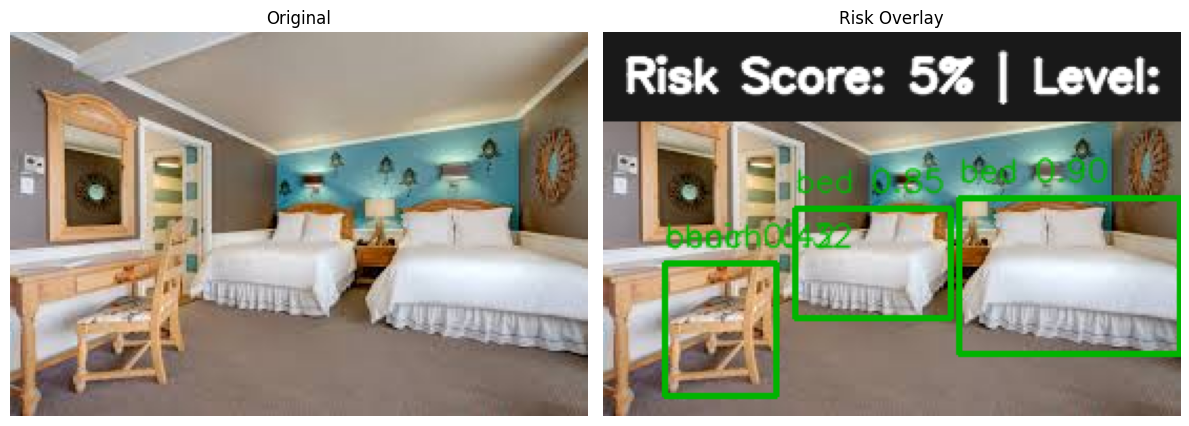

In [10]:
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(image_rgb)
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(overlay_rgb)
ax[1].set_title('Risk Overlay')
ax[1].axis('off')

plt.tight_layout()
plt.show()